
# Universe Simulator: Dark Matter & Cosmic Structure

*Notebook created using Claude on 2026/09/01*

This notebook builds a simplified **cosmological structure-formation simulator** and uses it
to show *why* dark matter is responsible for the "cosmic web" of galaxy superstructures —
filaments, clusters, and voids — and why a universe with **no dark matter** stays nearly
**homogeneous** (smooth and featureless).

### The physics in a nutshell

1. The early universe starts out almost perfectly smooth, with only tiny (~1 part in 100,000)
   density ripples imprinted by quantum fluctuations during inflation.
2. Gravity is an amplifier: regions that start out very slightly denser than average pull in
   more matter, growing denser still, while underdense regions get emptied out into voids.
3. **Ordinary (baryonic) matter alone grows structure very slowly**, because it's locked to
   radiation pressure until recombination (~380,000 years after the Big Bang) — radiation
   pressure resists gravitational collapse.
4. **Dark matter doesn't interact with light**, so it starts collapsing gravitationally much
   earlier and much faster. It builds the gravitational "scaffolding" — the cosmic web — that
   ordinary matter later falls into, forming the galaxies and clusters we see.
5. The more dark matter there is (relative to the total mass-energy budget), the *stronger*
   the effective gravitational amplification of those initial ripples, and the more dramatic
   the resulting web of filaments, clusters, and voids.

We can't run a real N-body simulation with billions of particles in a notebook, but we *can*
capture the essential physics with the **Zel'dovich approximation** — the same technique
cosmologists use to generate initial conditions for real N-body simulations (e.g. the
Millennium Simulation, IllustrisTNG). It says: take particles on a perfectly uniform grid,
and displace each one along the gradient of the gravitational potential sourced by the initial
density ripples. The *amount* of displacement (the "growth factor") stands in for how much
gravitational amplification has occurred — which is exactly what more or less dark matter
controls.

**In this simulation, the `dm_fraction` parameter scales the growth factor.**
- `dm_fraction = 0` &rarr; no gravitational amplification &rarr; particles stay on their
  starting grid &rarr; **homogeneous universe**.
- `dm_fraction = 1` &rarr; full amplification &rarr; particles collapse into a rich
  **cosmic web** of filaments, walls, clusters, and voids.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, maximum_filter

plt.rcParams['figure.facecolor'] = 'white'



## 1. Generate the primordial density field

We start by generating a **Gaussian random field** with a power spectrum $P(k) \sim k^{n}$.
This mimics the near-scale-invariant density ripples left over from inflation. The same
initial field (same random seed) is reused for every `dm_fraction` value below, so that the
*only* thing that changes between panels is how strongly gravity has amplified those same
initial ripples — an apples-to-apples comparison.


In [3]:
def generate_density_field(N, power_index=-1.2, seed=0):
    '''Gaussian random field with power spectrum P(k) ~ k^power_index.'''
    rng = np.random.default_rng(seed)
    white = rng.normal(size=(N, N))
    fk = np.fft.fft2(white)

    k1d = np.fft.fftfreq(N) * N
    KX, KY = np.meshgrid(k1d, k1d, indexing='ij')
    k = np.sqrt(KX**2 + KY**2)
    k[0, 0] = 1.0  # avoid divide-by-zero at k=0 (the mean)

    Pk = k**power_index
    Pk[0, 0] = 0.0  # zero mean density contrast

    fk *= np.sqrt(Pk)
    delta = np.fft.ifft2(fk).real
    delta /= np.std(delta)  # normalize so contrast amplitude is O(1)
    return delta



## 2. Solve for the gravitational displacement field (Zel'dovich approximation)

Given the density field $\delta$, we solve Poisson's equation $\nabla^2\phi = \delta$ for the
gravitational potential $\phi$, then compute the displacement each particle feels,
$\vec\psi = -\nabla\phi$. This pulls particles from underdense regions towards overdense
peaks — exactly what gravity does.


In [4]:
def zeldovich_displacement(delta, N):
    '''Solve nabla^2 phi = delta in Fourier space, return displacement field psi = -grad(phi).'''
    k1d = np.fft.fftfreq(N) * N
    KX, KY = np.meshgrid(k1d, k1d, indexing='ij')
    k2 = KX**2 + KY**2
    k2[0, 0] = 1.0

    delta_k = np.fft.fft2(delta)
    phi_k = delta_k / k2          # potential wells sit at density peaks
    phi_k[0, 0] = 0.0

    psi_x = np.fft.ifft2(-1j * KX * phi_k).real   # psi = -grad(phi): pulls particles INTO overdensities
    psi_y = np.fft.ifft2(-1j * KY * phi_k).real
    return psi_x, psi_y


def simulate_universe(N=200, dm_fraction=1.0, power_index=-1.2, seed=7, max_growth=22.0):
    '''
    Displace a uniform grid of particles according to the Zel'dovich approximation.

    dm_fraction : float in [0, 1] (or beyond, for fun)
        Stand-in for the amount of gravitationally-interacting (dark) matter.
        Scales the 'growth factor' -- i.e. how far gravity has been able to pull
        particles from their starting positions. dm_fraction=0 -> no displacement
        at all -> perfectly homogeneous universe.
    max_growth : float
        Overall scale of the displacement at dm_fraction=1. Tuned so the N=200
        grid produces a visually clear, but not fully collapsed, cosmic web.
    '''
    delta0 = generate_density_field(N, power_index=power_index, seed=seed)
    psi_x, psi_y = zeldovich_displacement(delta0, N)

    lin = np.arange(N)
    X, Y = np.meshgrid(lin, lin, indexing='ij')

    growth = dm_fraction * max_growth
    posX = (X + growth * psi_x) % N   # periodic boundary conditions
    posY = (Y + growth * psi_y) % N
    return posX, posY


def density_map(posX, posY, N, smoothing=1.5):
    '''Bin particles onto a grid and smooth to get a continuous density field.'''
    H, _, _ = np.histogram2d(posX.ravel(), posY.ravel(), bins=N, range=[[0, N], [0, N]])
    return gaussian_filter(H, sigma=smoothing)



## 3. Particle distributions: homogeneous &rarr; cosmic web

Watch what happens to the *same* initial density ripples as we dial `dm_fraction` from 0 to 1.


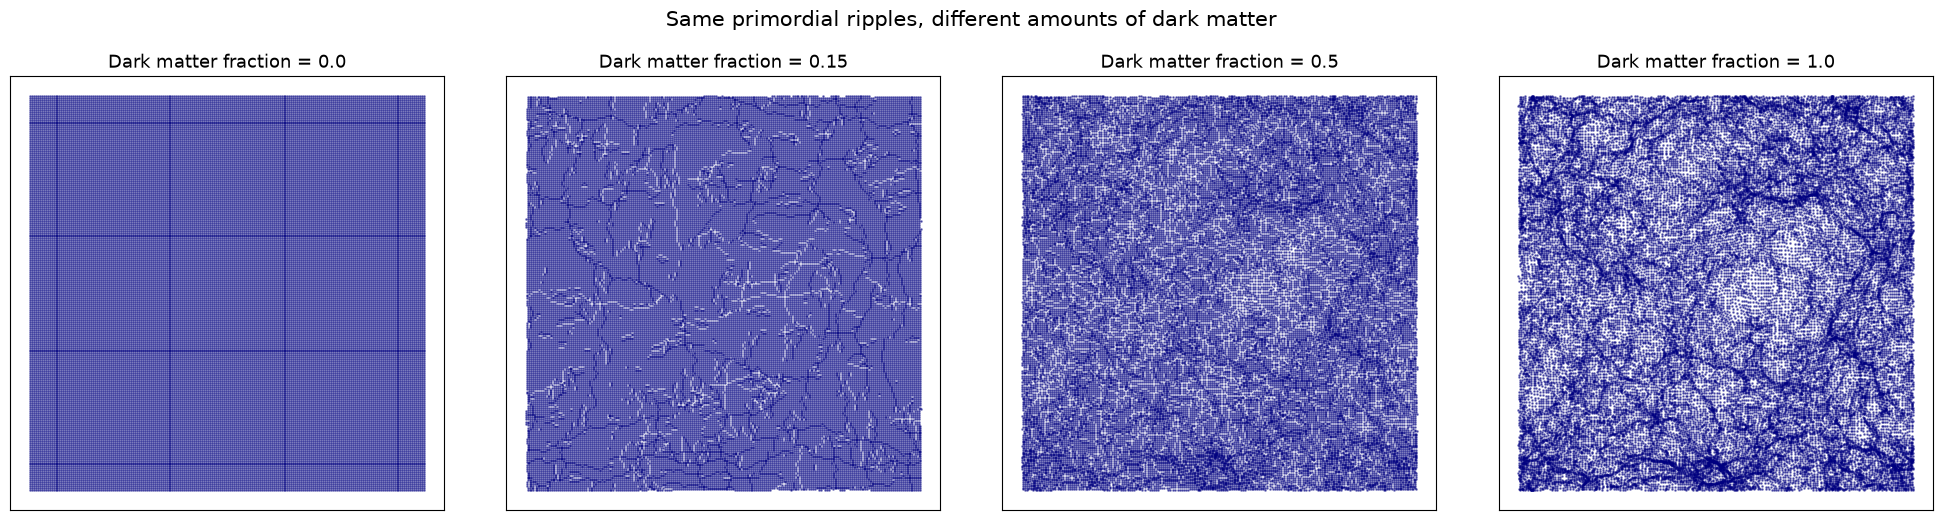

In [9]:
N = 200
fractions = [0.0, 0.15, 0.5, 1.0]

fig, axes = plt.subplots(1, len(fractions), figsize=(20, 5))
for ax, f in zip(axes, fractions):
    posX, posY = simulate_universe(N=N, dm_fraction=f)
    ax.scatter(posX, posY, s=0.8, alpha=0.5, color='navy')
    ax.set_title(f"Dark matter fraction = {f}", fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')

fig.suptitle("Same primordial ripples, different amounts of dark matter", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()



With **no dark matter** the particles never move off their starting grid: a perfectly
**homogeneous** universe, exactly as we'd expect if gravity were too weak (or too slow, as
with baryons alone) to amplify the primordial ripples before the present day.

As `dm_fraction` increases, the same tiny initial ripples get amplified into visible
structure: first gentle waviness, then filaments and walls, and finally (at `dm_fraction = 1`)
a genuine **cosmic web** — dense filaments and knots (proto-clusters of galaxies) surrounding
large near-empty voids.



## 4. Density field view (with voids & clusters highlighted)

Scatter plots make the web visible, but a smoothed **density heatmap** makes the emerging
voids and clusters much clearer.


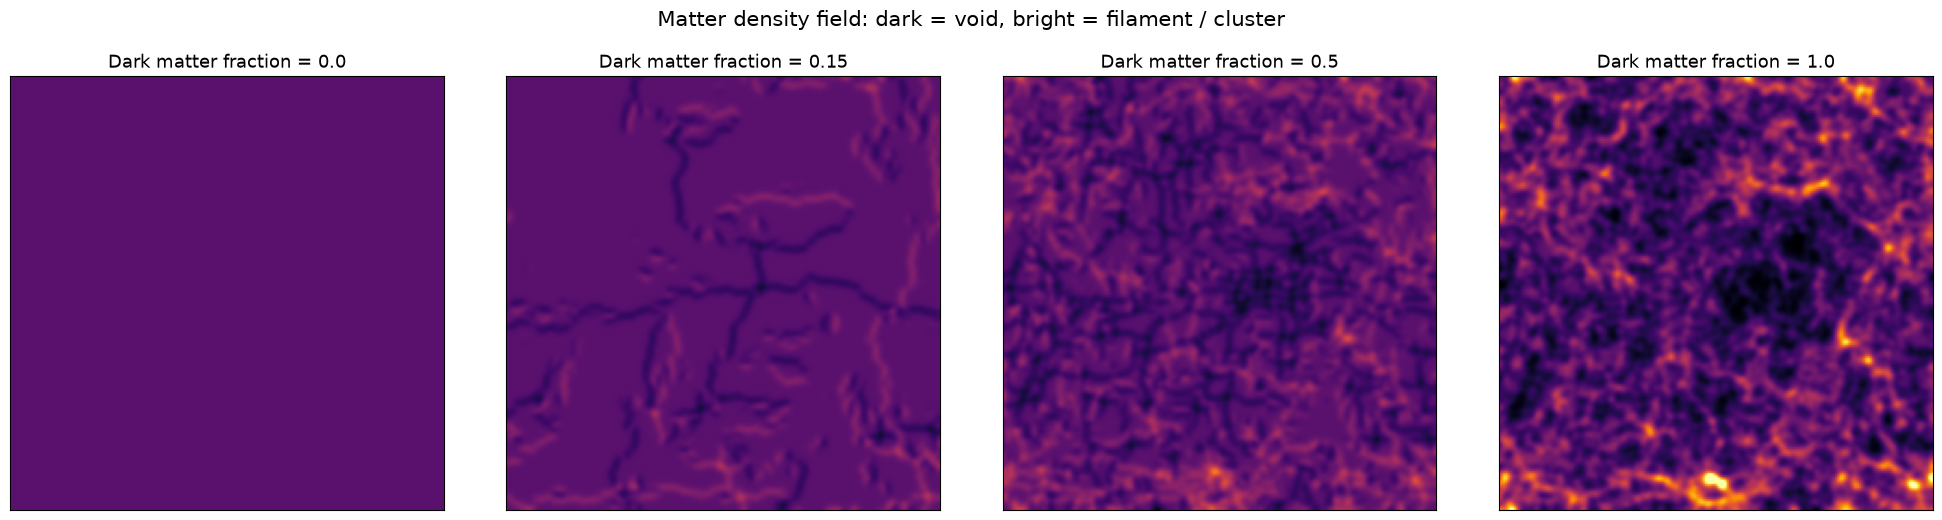

In [6]:
fig, axes = plt.subplots(1, len(fractions), figsize=(20, 5))

for ax, f in zip(axes, fractions):
    posX, posY = simulate_universe(N=N, dm_fraction=f)
    dens = density_map(posX, posY, N)
    im = ax.imshow(dens.T, origin='lower', cmap='inferno', vmin=0.3, vmax=3.0)
    ax.set_title(f"Dark matter fraction = {f}", fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Matter density field: dark = void, bright = filament / cluster", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()



## 5. Quantifying it: void fraction & cluster fraction vs. dark matter

Let's put a number on what our eyes are telling us. For a range of `dm_fraction` values we
compute:

- **Void fraction**: the fraction of the universe's area that is significantly *underdense*
  (density below 70% of the mean) — i.e. how much of space is emptied out into voids.
- **Cluster fraction**: the fraction that is significantly *overdense* (density above 2x the
  mean) — i.e. how much matter has collapsed into dense clusters/filaments.

In a real universe, both of these grow with time as structure formation proceeds — and here,
both grow with `dm_fraction`, since more (effective) gravitating matter means more
amplification of the same initial ripples.


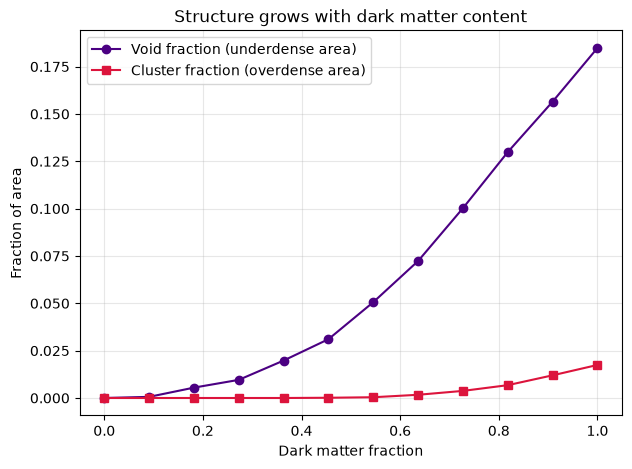

In [7]:
dm_values = np.linspace(0.0, 1.0, 12)
void_fracs, cluster_fracs = [], []

for f in dm_values:
    posX, posY = simulate_universe(N=N, dm_fraction=f)
    dens = density_map(posX, posY, N)
    void_fracs.append(np.mean(dens < 0.7 * dens.mean()))
    cluster_fracs.append(np.mean(dens > 2.0 * dens.mean()))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(dm_values, void_fracs, 'o-', color='indigo', label='Void fraction (underdense area)')
ax.plot(dm_values, cluster_fracs, 's-', color='crimson', label='Cluster fraction (overdense area)')
ax.set_xlabel('Dark matter fraction')
ax.set_ylabel('Fraction of area')
ax.set_title('Structure grows with dark matter content')
ax.legend()
ax.grid(alpha=0.3)
plt.show()



## 6. Try it yourself

Change `my_dm_fraction` below (anywhere from `0.0` to `1.0`, or push it above 1 to see a
"more dark matter than our universe has" scenario) and re-run the cell.


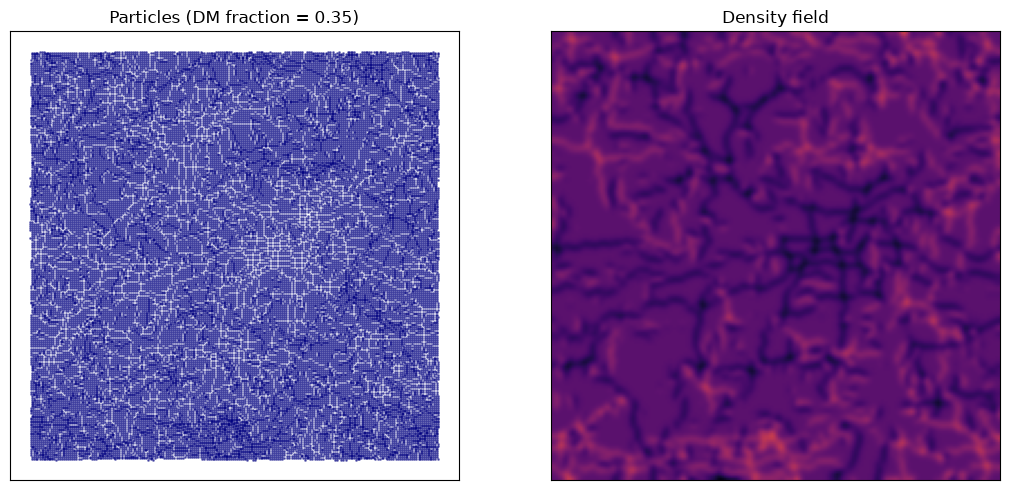

Void fraction:    0.019
Cluster fraction: 0.0000


In [8]:
my_dm_fraction = 0.35  # <-- change this and re-run!

posX, posY = simulate_universe(N=N, dm_fraction=my_dm_fraction)
dens = density_map(posX, posY, N)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(posX, posY, s=1, alpha=0.5, color='navy')
axes[0].set_title(f"Particles (DM fraction = {my_dm_fraction})")
axes[0].set_xticks([]); axes[0].set_yticks([]); axes[0].set_aspect('equal')

axes[1].imshow(dens.T, origin='lower', cmap='inferno', vmin=0.3, vmax=3.0)
axes[1].set_title("Density field")
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
plt.show()

print(f"Void fraction:    {np.mean(dens < 0.7*dens.mean()):.3f}")
print(f"Cluster fraction: {np.mean(dens > 2.0*dens.mean()):.4f}")



## Notes & caveats (so this stays honest science communication)

- This is a **2D, single-step Zel'dovich approximation**, not a full 3D N-body simulation. Real
  simulations (like IllustrisTNG or the Millennium Simulation) evolve billions of particles
  over many timesteps including nonlinear gravity, gas physics, and feedback from stars and
  black holes.
- `dm_fraction` here is a simplified stand-in for "how much gravitational amplification has
  occurred," which in reality depends on both the amount of dark matter *and* how much cosmic
  time has passed. The qualitative story it teaches is real and correct: **more gravitating
  (dark) matter -> stronger amplification of primordial density ripples -> more pronounced
  cosmic web**, and **no dark matter -> a universe that stays close to homogeneous** because
  ordinary matter alone can't collapse fast enough to build the structures we observe (galaxy
  filaments, walls, and voids) within the age of the universe.
- The real observational evidence for this story includes the **cosmic microwave background**
  power spectrum, the **large-scale galaxy distribution** (e.g. SDSS, 2dF surveys), and
  **gravitational lensing** maps of dark matter.
